# Dielectric Function versus NBANDS, k-points, and algorithms

Dielectric function versus Photon energy in different NBANDS, k-points, and algorithms

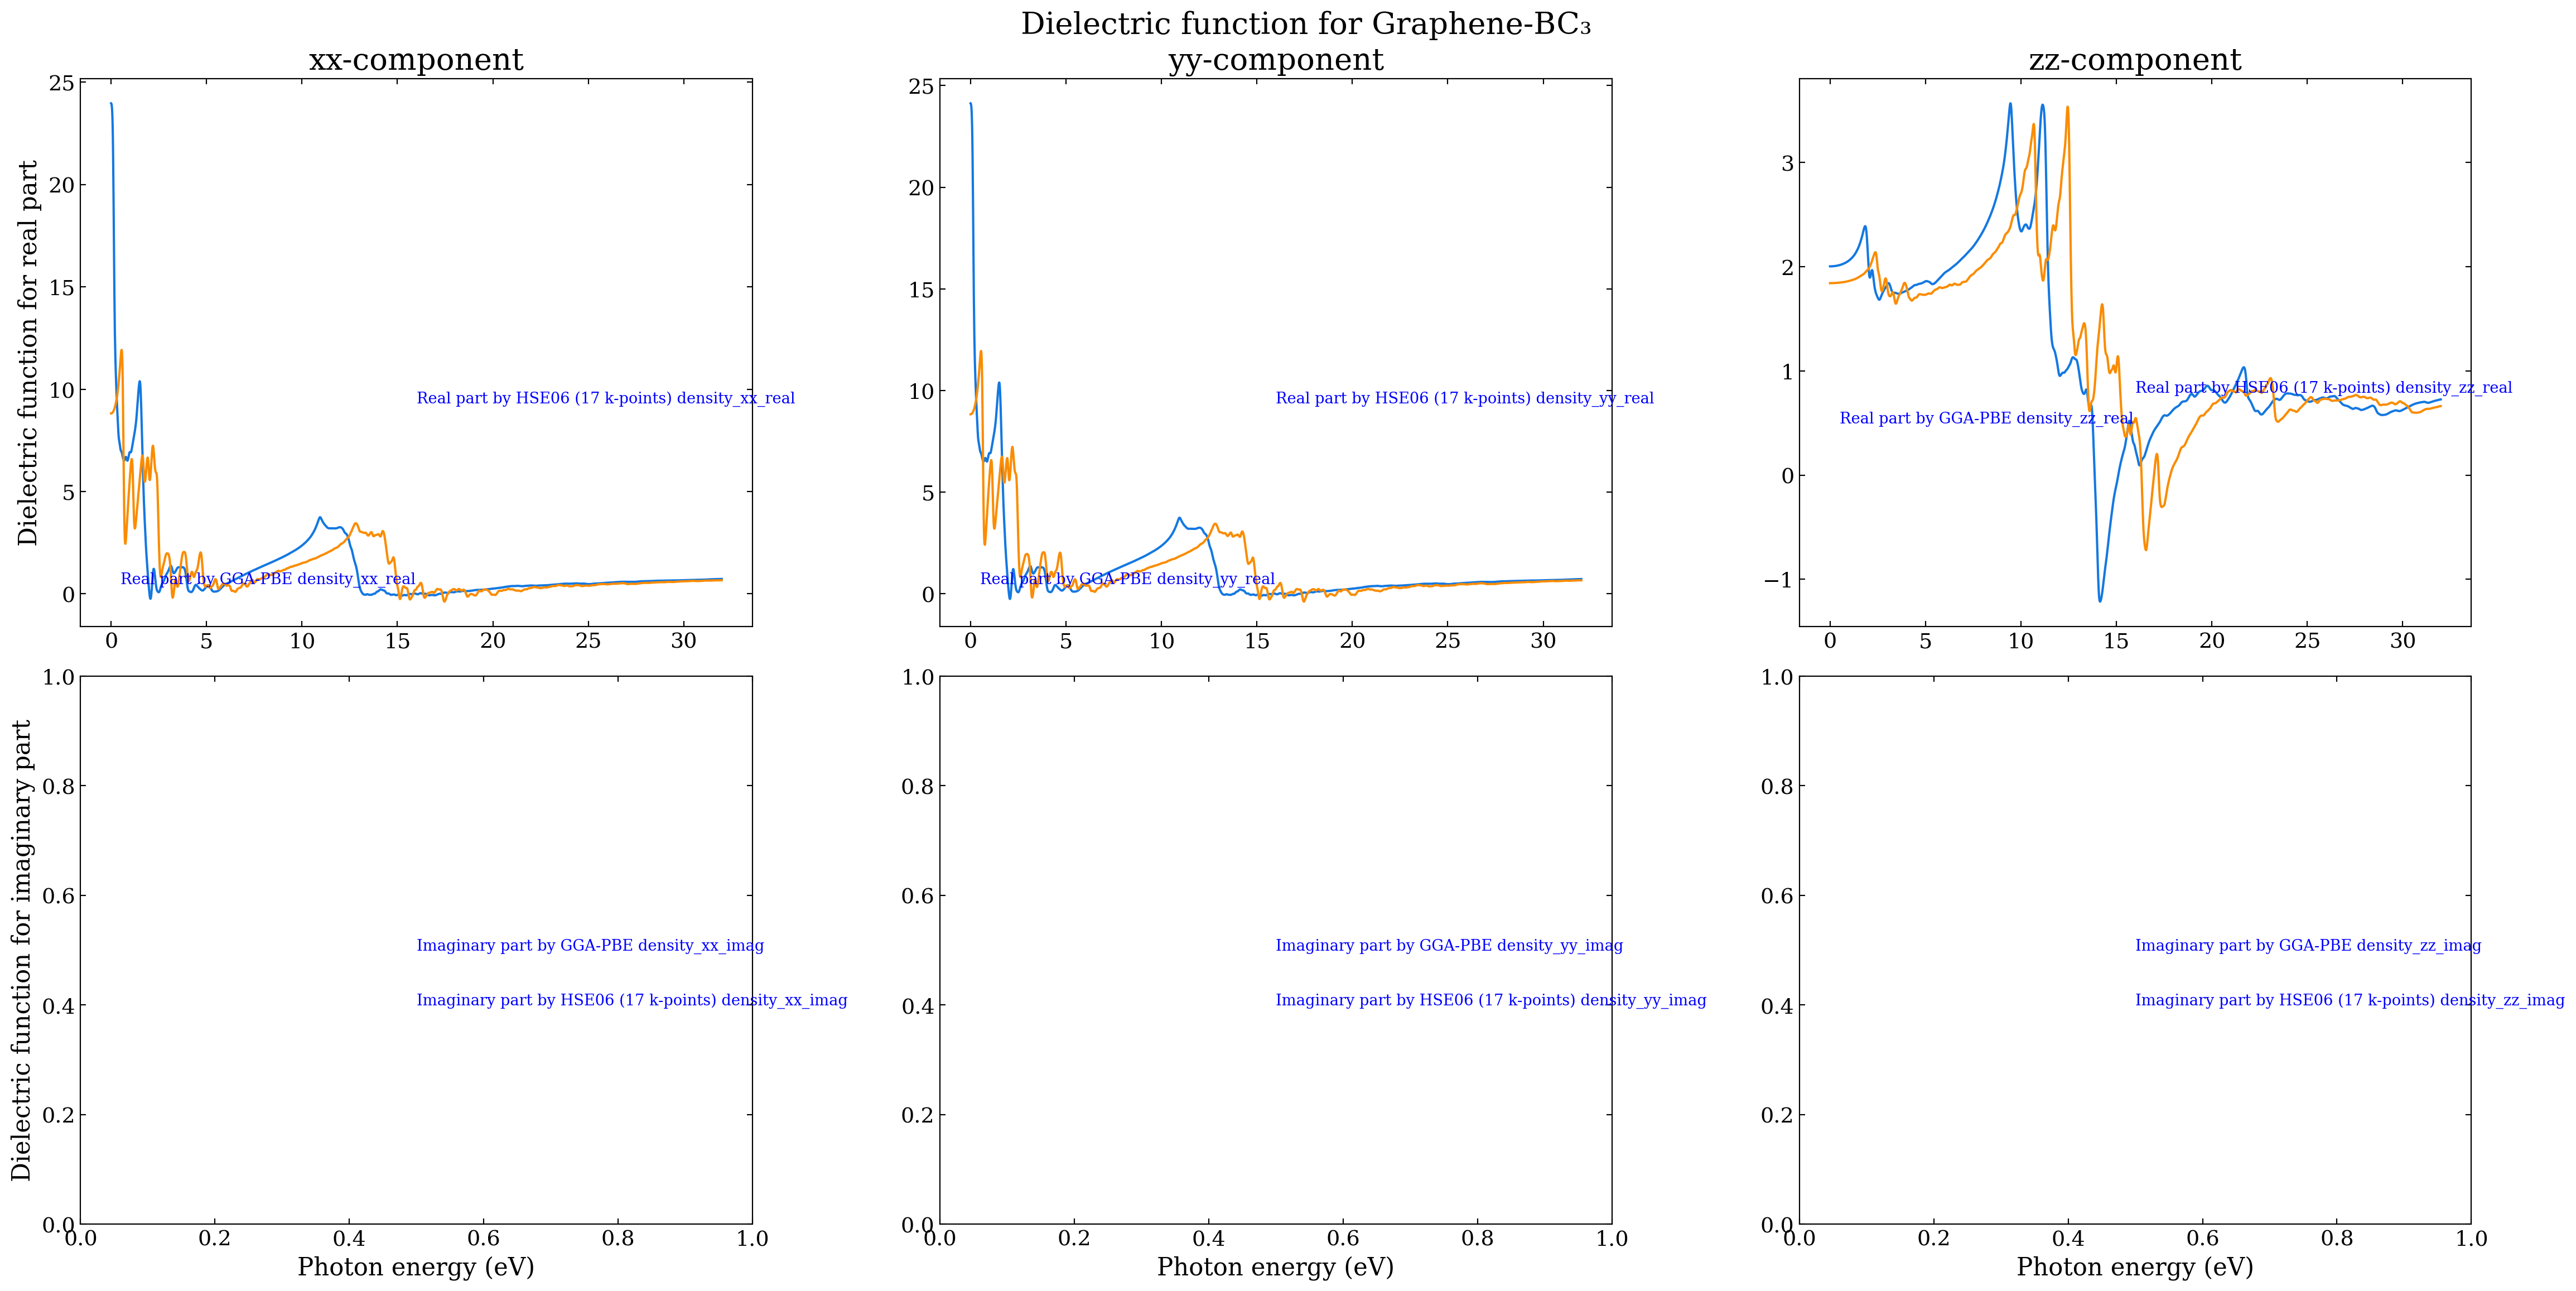

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

from vmatplot.output import canvas_setting, color_sampling
from vmatplot.algorithms import process_boundary, extract_part, energy_to_wavelength
from vmatplot.dielectric_function import extract_dielectric_function, dielectric_systems_list

# data = dielectric_function_list(systems)
    # data[0] = current curve label
    # data[1] = dielectric function data
    # data[2] = color family
    # data[3] = linestyle
    # data[4] = alpha
    # data[5] = linewidth

def identify_components(input):
    if input == "xx": return "density_xx_real","density_xx_imag"
    elif input == "yy": return "density_yy_real","density_yy_imag"
    elif input == "zz": return "density_zz_real","density_zz_imag"
    elif input == "xy": return "density_xy_real","density_xy_imag"
    elif input == "yx": return "density_yx_real","density_yx_imag"
    elif input == "yz": return "density_yz_real","density_yz_imag"
    elif input == "zy": return "density_zy_real","density_zy_imag"
    elif input == "zx": return "density_zx_real","density_zx_imag"
    elif input == "xz": return "density_xz_real","density_xz_imag"

# def plot_dielectric_function_com

def plot_dielectric_function_sep(suptitle, systems=None, components=None, comp_aliases=None,
                                 layout=None, unit=None, boundary=(None, None), figure_size=(None,None)):
    ## Help information
    help_info = "Usage: plot_dielectric_function" + \
                "The independent value includes \n" +\
                "\t the suptitle, \n" +\
                "\t dielectric function data list, \n" +\
                "\t components:('xx'<default>, 'yy', 'zz', 'xy', 'yx', 'yz', 'zy', 'zx', 'xz'), \n" +\
                "\t the aliases of selected components, \n" +\
                "\t subfigures layout (horizontal<default>, vertical), \n" +\
                "\t x-axis unit (eV<default>, nm), \n" +\
                "\t a-axis range <optional>, \n" +\
                "\t figure size <optional>. \n"
    if suptitle in ["help", "Help"]:
        print(help_info)

    ## figure settings
    if layout is None or layout.lower() not in ["hor", "horizontal"]:
        fig_setting = canvas_setting(16, 6*len(components)) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
        params = fig_setting[2]; plt.rcParams.update(params)
        fig, axs = plt.subplots(len(components), 2, figsize=fig_setting[0], dpi=fig_setting[1])
        axes_element = [axs[i, j] for i in range(len(components)) for j in range(2)] if len(components) != 1 else [axs[0], axs[1]]
        layout_label = "vertical"
    else:
        fig_setting = canvas_setting(8*len(components), 12) if figure_size == (None, None) else canvas_setting(figure_size[0], figure_size[1])
        params = fig_setting[2]; plt.rcParams.update(params)
        fig, axs = plt.subplots(2, len(components), figsize=fig_setting[0], dpi=fig_setting[1])
        axes_element = [axs[i, j] for j in range(len(components)) for i in range(2)] if len(components) != 1 else [axs[0], axs[1]]
        layout_label = "horizontal"

    ## identify x-axis unit
    var_label = "wavelength" if unit and unit.lower() == "nm" else "energy"
    xaxis_label = "Photon wavelength (nm)" if var_label == "wavelength" else "Photon energy (eV)"
    
    ## systems information
    dataset = dielectric_systems_list(systems)
    component_keys = [comp.lower() + "-component" for comp in components] if not comp_aliases else comp_aliases
    # subtitle_keys = [key for key in component_keys for _ in range(2)]
    # subtitles = [f"{item} real part" if i % 2 == 0 else f"{item} imaginary part" for i, item in enumerate(subtitle_keys)]
    # print(component_keys) # ['xx-component', 'yy-component', 'zz-component', ...]

    ## suptitle
    fig.suptitle(f"Dielectric function {suptitle}", fontsize=fig_setting[3][0])

    ## data boundary
    photon_start, photon_end = process_boundary(boundary)

    ## data plotting
    # for each subplot
    for supplot_index in range(2*len(components)):
        ax = axes_element[supplot_index]
        ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
        # ax.set_title(subtitles[supplot_index])
 
        # current component index and label
        component_index = supplot_index//2
        current_component = components[component_index].lower()
        data_key = f"density_{current_component}_real" if supplot_index%2 == 0 else f"density_{current_component}_imag"
        # print(data_key) # density_xx_real, density_xx_imag, density_yy_real, density_yy_imag, density_zz_real, density_zz_imag

        # subtitles and axis label (self-assertive)
        if layout_label == "vertical" and supplot_index in range(2):
            ax.set_title(["Real part", "Imaginary part"][supplot_index])
        elif layout_label == "horizontal" and supplot_index%2 == 0:
            ax.set_title(component_keys[component_index])
        if layout_label == "vertical" and supplot_index%2 == 0:
            ax.set_ylabel(f"Dielectric function for {component_keys[component_index]}")
        elif layout_label == "horizontal" and supplot_index in range(2):
            ax.set_ylabel(f"Dielectric function for {['real part', 'imaginary part'][supplot_index]}")
        if layout_label == "vertical" and supplot_index >= 2*len(components)-2:
            ax.set_xlabel(xaxis_label)
        elif layout_label == "horizontal" and supplot_index%2 == 1:
            ax.set_xlabel(xaxis_label)

        # initialization
        wavelength_starts = []; wavelength_ends = []; energy_starts = []; energy_ends=[]

        # real part
        if supplot_index%2 == 0:
            # for each system
            for systems_index, data in enumerate(dataset):
                ax.text((ax.get_xlim()[0]+ax.get_xlim()[1])/2, (ax.get_ylim()[0]+ax.get_ylim()[1])/2-systems_index*0.1*ax.get_ylim()[1], f"Real part {data[0]} {data_key}", color="blue")
                energy_real, density_real = extract_part(data[1]["density_energy_real"], data[1][data_key], photon_start, photon_end)
                if var_label == "energy":
                    ax.plot(energy_real, density_real, color=color_sampling(data[2])[1], ls=data[3], alpha=data[4], lw=data[5], label=f"Real part {data[0]}")
                # else:
        # imaginary part
        else:
            for systems_index, data in enumerate(dataset):
                ax.text((ax.get_xlim()[0]+ax.get_xlim()[1])/2, (ax.get_ylim()[0]+ax.get_ylim()[1])/2-systems_index*0.1*ax.get_ylim()[1], f"Imaginary part {data[0]} {data_key}", color="blue")
                data_label = f"Imaginary part {data[0]}"
                energy_imag, density_imag = extract_part(data[1]["density_energy_imag"], data[1][data_key], photon_start, photon_end)

    plt.tight_layout()

#### testing area

# Graphene-BC₃ (Hollow)

dielectric_list = [["by GGA-PBE", "5_Dielectric_function/E_Graphene-BC3_PBE_K65_Normal", "blue"],
                   ["by HSE06 (17 k-points)", "5_Dielectric_function/E_Graphene-BC3_HSE_K17", "orange"]]


# plot_dielectric_function_sep("for Graphene-BC₃", dielectric_list, ["xx"])

# plot_dielectric_function_sep("for Graphene-BC₃", dielectric_list, ["xx"],"","hor")

# plot_dielectric_function_sep("for Graphene-BC₃", dielectric_list, ["xx", "yy"])

# plot_dielectric_function_sep("for Graphene-BC₃", dielectric_list, ["xx", "zz"],"","hor","eV",32)

# plot_dielectric_function_sep("for Graphene-BC₃", dielectric_list, ["zz", "xx", "yy"])

plot_dielectric_function_sep("for Graphene-BC₃", dielectric_list, ["xx", "yy", "zz"],"","hor","eV",32)

